# ENVS 407 - Snow Hydrology 
## Snowpack Energy Balance Problem 

* Solving the in class snowpack energy balance problem in python

created by Cassie Lumbrazo\
last updated: March 2026

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib 
import matplotlib.pyplot as plt

# data packages 
import pandas as pd
import numpy as np

## Snowpack Energy Balance 
### During Clear Sky Winter Conditions

We compute snowpack internal energy using:

$$
Q_i = Q_{ns} + Q_{nl} + Q_h + Q_e + Q_r + Q_g + Q_m
$$

Given:

$$
Q_r = Q_g = Q_m = 0
$$

Therefore:

$$
Q_i = Q_{ns} + Q_{nl} + Q_h + Q_e
$$

All fluxes are expressed in W m².

### Let's set up the problem with constants

In [2]:
# ---------------------------------------------------
# GIVEN CONDITIONS
# ---------------------------------------------------

Kin = 82          # Incoming shortwave radiation [W m^-2]
albedo = 0.78     # Snow surface albedo [-]

Ts_C = -2         # Snow surface temperature [deg C]
Ta_C = 1          # Air temperature at 2 m [deg C]

Pa_mb = 1014      # Atmospheric pressure [mb]
Ea_mb = 4.2       # Air vapor pressure at 2 m [mb]
Eo_mb = 5.9       # Vapor pressure at snow surface [mb]

Zo = 0.001        # Snow surface roughness length [m]
Za = 2            # Measurement height [m]
Ua = 2.5          # Wind speed at height Za [m s^-1]

rho_a = 1.25      # Air density [kg m^-3]
cp = 1000         # Specific heat of air [J kg^-1 K^-1]

Ls = 2.8e6        # Latent heat of sublimation [J kg^-1]
sigma = 5.67e-8   # Stefan-Boltzmann constant [W m^-2 K^-4]
k = 0.4           # von Karman constant [-]

### Unit Conversions

Temperatures must be converted to Kelvin:

$$
T(K) = T(^\circ C) + 273.15
$$

Pressure and vapor pressure must be converted:

$$
1 \text{ mb} = 100 \text{ Pa}
$$

In [3]:
# Unit Conversations
Ts = Ts_C + 273.15
Ta = Ta_C + 273.15

Pa = Pa_mb * 100
Ea = Ea_mb * 100
Eo = Eo_mb * 100

print(f"Ts (K) = {Ts:.2f}")
print(f"Ta (K) = {Ta:.2f}")

Ts (K) = 271.15
Ta (K) = 274.15


### Qns: Net Shortwave Radiation (Eq. 6.2)​

$$
Q_{ns} = K_{in} - (\alpha  K_{in})
$$
which can also be written as, 
$$
Q_{ns} = (1 - \alpha) K_{in}
$$

In [4]:
Qns = Kin - (albedo * Kin)
# Qns = (1 - albedo) * Kin

print(f"Qns (Net Shortwave) = {Qns:.2f} W m²")

Qns (Net Shortwave) = 18.04 W m²


$$
Q_{ns} = 18.04 \ W m²  
$$

_____________________________________________
### Qns: Net Longwave Radiation (Eq. 6.10, 6.11, 6.12)

Outgoing longwave radiation (Eq. 6.11):

$$
L_{out} = \varepsilon \sigma T_s^4 + (1 - \varepsilon)L_{in}
$$

We will assume that for snow, emissivity is approximately equal to 1:

$$
\varepsilon = 1
$$

Therefore:

$$
L_{out} = \sigma T_s^4
$$

Clear-sky incoming longwave radiation (Eq. 6.12):

$$
L_{in} = (0.572 \, e_a^{1/7}) \sigma T_a^4
$$

Net longwave radiation (Eq. 6.10):

$$
Q_{nl} = L_{in} - L_{out}
$$

In [5]:
emissivity = 1.0   # Snow surface emissivity [-]

# Atmospheric emissivity (clear-sky parameterization) (Eq. 6.12)
epsilon_a = 0.572 * Ea_mb**(1/7)

# Incoming longwave radiation
Lin = epsilon_a * sigma * Ta**4

# Full outgoing longwave equation (Eq. 6.11)
Lout = emissivity * sigma * Ts**4 + (1 - emissivity) * Lin

# Net longwave radiation (Eq. 6.10)
Qnl = Lin - Lout

print(f"Emissivity = {emissivity:.2f}")
print(f"Lin  = {Lin:.2f} W m²")
print(f"Lout = {Lout:.2f} W m²")
print(f"Qnl (Net Longwave) = {Qnl:.2f} W m²")

Emissivity = 1.00
Lin  = 224.89 W m²
Lout = 306.49 W m²
Qnl (Net Longwave) = -81.60 W m²


$$
Q_{nl} = - 81.60 \ W m²  
$$

______________________________________
### Qh: Sensible Heat Exchange with the Atmosphere (Sensible Heat Flux) (Eq. 6.14, 6.15)

Neutral bulk transfer coefficient (Eq. 6.14):

$$
C_{hn} = \frac{k^2}{\left[\ln\left(\frac{z_a}{z_0}\right)\right]^2}
$$

Sensible heat flux (Eq. 6.15):

$$
Q_h = \rho_a c_p C_{hn} u_a (T_a - T_s)
$$

In [6]:
Chn = (k**2) / (np.log(Za / Zo)**2)

Qh = rho_a * cp * Chn * Ua * (Ta - Ts)

print(f"Chn = {Chn:.5f}")
print(f"Qh (Sensible Heat) = {Qh:.2f} W m²")

Chn = 0.00277
Qh (Sensible Heat) = 25.96 W m²


$$
Q_h = 25.96 \ W m²  
$$

____________________________________________
#### Qe: Latent Heat of Vaporization and Sublimiation with the Atmosphere (Latent Heat Flux) (Eq. 6.20)

Since the snow surface temperature is below 0°C, vapor exchange occurs over ice.

We use latent heat of sublimation:

$$
L = L_s
$$

Latent heat flux (Eq. 6.20):

$$
Q_e = \rho_a \left(\frac{0.622 L}{P_a}\right) C_{hn} u_a (e_a - e_0)
$$

and we use $C_{hn}$ calculated above with the sensible heat flux

In [7]:
Qe = rho_a * (0.622 * Ls / Pa) * Chn * Ua * (Ea - Eo)

print(f"Qe (Latent Heat) = {Qe:.2f} W m²")

Qe (Latent Heat) = -25.27 W m²


$$
Q_e = - 25.27 \ W m²  
$$

______________________________
### Total Snowpack Internal Energy

$$
Q_i = Q_{ns} + Q_{nl} + Q_h + Q_e
$$

In [8]:
Qi = Qns + Qnl + Qh + Qe

print(f"Qi (Total Snowpack Energy Balance) = {Qi:.2f} W m²")

Qi (Total Snowpack Energy Balance) = -62.87 W m²


$$
Q_i = - 62.87 \ W m²  
$$

### So, what does this mean? 

The total snowpack energy balance was calculated as:

$$
\ Q_i < 0
$$

A negative value of $Q_i$ means that the snowpack is losing energy to the atmosphere.

Under these clear-sky winter conditions:

- Net shortwave radiation provides a small energy gain.
- Sensible heat flux contributes a modest energy gain from warmer air.
- Net longwave radiation is strongly negative due to radiative cooling.
- Latent heat flux is negative, indicating sublimation (mass and energy loss).

There is insufficient energy available for melt.

Physically, this represents a clear-sky radiative cooling regime, where longwave emission dominates the surface energy exchange.

______________________________________

Let's try to make a little plot of this, just for fun...

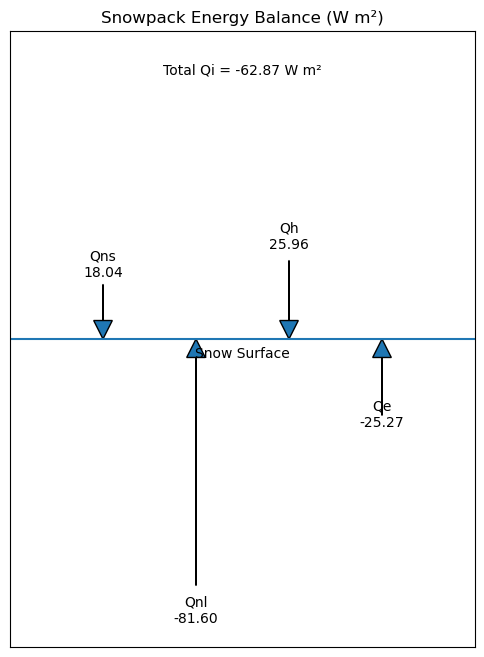

In [9]:
# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------
fluxes = {
    "Qns": Qns,
    "Qnl": Qnl,
    "Qh": Qh,
    "Qe": Qe
}

plt.figure(figsize=(6,8))

# Snow surface line
plt.axhline(0)
plt.text(0, -0.3, "Snow Surface", ha='center')

x_positions = [-1.5, -0.5, 0.5, 1.5]

# Scale arrows based on largest magnitude
max_flux = max(abs(v) for v in fluxes.values())
scale = 4 / max_flux

for (label, value), x in zip(fluxes.items(), x_positions):
    arrow_length = value * scale

    # Draw arrow (positive downward = energy gain)
    plt.arrow(x, arrow_length, 0, -arrow_length,
              length_includes_head=True, head_width=0.2)

    plt.text(x, arrow_length*1.15,
             f"{label}\n{value:.2f}",
             ha='center')

plt.xlim(-2.5, 2.5)
plt.ylim(-5, 5)
plt.xticks([])
plt.yticks([])
plt.title("Snowpack Energy Balance (W m²)")

plt.text(0, 4.3,
         f"Total Qi = {Qi:.2f} W m²",
         ha='center')

plt.show()

__________________________